<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_splitter_sensitivity_final_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Splitter Sensitivity Check

## Is the very low repeat-to-repeat variance caused by the optimized splitter?

This notebook tests **one narrow question** before the capstone result is finalized.

The previous repeated balanced validation found:

- Random Forest mean Precision@100 ≈ **76.3%**
- Momentum mean Precision@100 ≈ **72.6%**
- RF mean lift ≈ **+3.7 percentage points**
- between-repeat SD of the RF mean ≈ **0.7 percentage points**
- only **5 unique optimized partitions** were found when 10 were requested

That raised a reasonable concern:

> The optimized balanced splitter may repeatedly converge to very similar client assignments, making the between-repeat variance look smaller than it really is.

### This notebook changes only the splitter

Everything else stays fixed:

- same March feature/outcome boundary;
- same leakage guard;
- same Full-Signal features;
- same Random Forest settings;
- same Momentum baseline;
- same Precision@100 metric;
- client-disjoint validation.

We compare:

1. **Optimized balanced splitter** — balances client count, rows, positives, and base rate.
2. **Random balanced splitter** — balances **client count only** and deliberately does not optimize rows or target balance.

The random splitter is a **stress test**, not a replacement for the primary validator.

If the RF result and its lift over Momentum remain similar under genuinely different random balanced partitions, the capstone conclusion is much more defensible.


In [1]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from getpass import getpass

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
PRIMARY_K = 100
MACRO_K = 10
DECLINE_THRESHOLD_PCT = -20.0
N_SPLITS = 5
SIMPLICITY_TIE_PP = 1.0

np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1


## 1. Connect to the approved FlyRank warehouse

The token is read from Colab Secrets when available. It is never hardcoded or printed.

In [3]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your Hugging Face READ token: ")

if not HF_TOKEN:
    raise ValueError("A Hugging Face READ token is required.")

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

print("Connected successfully.")

Connected successfully.


## 2. Build a temporally clean modeling table

Prediction time is the end of **March 15, 2026**.

- Feature window: **March 1–15**
- Outcome window: **March 16–31**

The 15 feature days are also split into three 5-day blocks. Those blocks let us describe whether a decline is **accelerating, decelerating, or inconsistent**, instead of relying only on one early-vs-late momentum number.

The original 7-day / 8-day momentum definition is kept as the transparent anchor for comparability with the previous notebook.

In [4]:
query = f"""
SELECT
    client_hash_id AS client_id,
    content_hash_id AS content_id,

    -- Three equal pre-outcome blocks: Mar 1-5, 6-10, 11-15.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w1,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w2,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w3,

    -- Original momentum anchor: Mar 1-7 vs Mar 8-15.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_early7,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_late8,

    -- Coverage checks.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_features,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_future,

    -- Outcome only. Never enters the feature set.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_future

FROM {FACT_MARCH}
WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
GROUP BY client_hash_id, content_hash_id
"""

raw_df = con.execute(query).df()

print("Rows returned:", len(raw_df))
print("Clients returned:", raw_df["client_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows returned: 331437
Clients returned: 55


## 3. Create the pre-outcome feature population first

This ordering matters.

Client-relative percentiles should describe what was knowable **at prediction time**. Therefore we first create the population with complete March 1–15 feature coverage, engineer every pre-outcome feature, and compute within-client ranks there.

Only **after that** do we restrict to pages with complete March 16–31 outcome coverage for evaluation.

In [5]:
feature_population = raw_df[raw_df["gsc_days_features"] == 15].copy()

feature_population["imp_first_half"] = (
    feature_population["imp_w1"]
    + feature_population["imp_w2"]
    + feature_population["imp_w3"]
)
feature_population["clicks_first_half"] = (
    feature_population["clicks_w1"]
    + feature_population["clicks_w2"]
    + feature_population["clicks_w3"]
)
feature_population["sum_position_first_half"] = (
    feature_population["sum_position_w1"]
    + feature_population["sum_position_w2"]
    + feature_population["sum_position_w3"]
)
feature_population["active_days_first_half"] = (
    feature_population["active_days_w1"]
    + feature_population["active_days_w2"]
    + feature_population["active_days_w3"]
)

# We need a non-zero pre-outcome reference level and a defined average position.
feature_population = feature_population[
    feature_population["imp_first_half"] > 0
].copy()

feature_population["avg_position_first_half"] = (
    feature_population["sum_position_first_half"]
    / feature_population["imp_first_half"]
)
feature_population = feature_population[
    feature_population["avg_position_first_half"].notna()
    & (feature_population["avg_position_first_half"] > 0)
].copy()

print("Feature-eligible pages before future filtering:", len(feature_population))
print("Feature-eligible clients:", feature_population["client_id"].nunique())

Feature-eligible pages before future filtering: 68288
Feature-eligible clients: 35


## 4. Engineer the signal above momentum

We separate features into three groups.

### A. Momentum anchor
The exact early-vs-late signal used by the simple heuristic.

### B. Context signal
Information that can explain **when a momentum decline is more likely to persist**:

- traffic and click level,
- 5-day trend shape,
- acceleration / deceleration,
- decline consistency across subwindows,
- CTR change,
- search-position change,
- activity change,
- client-relative scale.

### C. Full ML feature set
Momentum anchor + context signal.

For the **model+momentum blend**, the model is trained only on the context signal. That avoids simply feeding the same momentum score to the model and then counting it again in the blend.

In [6]:
def safe_pct_change(new_value, old_value):
    denom = np.maximum(np.asarray(old_value, dtype=float), 1.0)
    return ((np.asarray(new_value, dtype=float) - np.asarray(old_value, dtype=float)) / denom) * 100.0


# Stable levels.
feature_population["log_imp_first_half"] = np.log1p(feature_population["imp_first_half"])
feature_population["log_clicks_first_half"] = np.log1p(feature_population["clicks_first_half"])
feature_population["ctr_first_half"] = (
    feature_population["clicks_first_half"] / feature_population["imp_first_half"]
) * 100.0
feature_population["active_rate_first_half"] = feature_population["active_days_first_half"] / 15.0

# Original momentum anchor: daily-normalized Mar 1-7 vs Mar 8-15.
feature_population["avg_daily_imp_early7"] = feature_population["imp_early7"] / 7.0
feature_population["avg_daily_imp_late8"] = feature_population["imp_late8"] / 8.0
feature_population["imp_momentum_pct"] = safe_pct_change(
    feature_population["avg_daily_imp_late8"],
    feature_population["avg_daily_imp_early7"],
)
feature_population["imp_momentum_log"] = (
    np.log1p(feature_population["avg_daily_imp_late8"])
    - np.log1p(feature_population["avg_daily_imp_early7"])
)

# Equal 5-day blocks reveal shape, not just one start-vs-end number.
for w in (1, 2, 3):
    feature_population[f"avg_daily_imp_w{w}"] = feature_population[f"imp_w{w}"] / 5.0
    feature_population[f"avg_daily_clicks_w{w}"] = feature_population[f"clicks_w{w}"] / 5.0
    feature_population[f"ctr_w{w}"] = np.where(
        feature_population[f"imp_w{w}"] > 0,
        (feature_population[f"clicks_w{w}"] / feature_population[f"imp_w{w}"]) * 100.0,
        0.0,
    )
    feature_population[f"avg_position_w{w}"] = np.where(
        feature_population[f"imp_w{w}"] > 0,
        feature_population[f"sum_position_w{w}"] / feature_population[f"imp_w{w}"],
        np.nan,
    )
    feature_population[f"active_rate_w{w}"] = feature_population[f"active_days_w{w}"] / 5.0

feature_population["imp_step12_log"] = (
    np.log1p(feature_population["avg_daily_imp_w2"])
    - np.log1p(feature_population["avg_daily_imp_w1"])
)
feature_population["imp_step23_log"] = (
    np.log1p(feature_population["avg_daily_imp_w3"])
    - np.log1p(feature_population["avg_daily_imp_w2"])
)
feature_population["imp_acceleration"] = (
    feature_population["imp_step23_log"] - feature_population["imp_step12_log"]
)
feature_population["imp_declining_steps"] = (
    (feature_population["avg_daily_imp_w2"] < feature_population["avg_daily_imp_w1"]).astype(int)
    + (feature_population["avg_daily_imp_w3"] < feature_population["avg_daily_imp_w2"]).astype(int)
)
feature_population["imp_recent_vs_prior_log"] = (
    np.log1p(feature_population["avg_daily_imp_w3"])
    - np.log1p(
        (feature_population["avg_daily_imp_w1"] + feature_population["avg_daily_imp_w2"]) / 2.0
    )
)
feature_population["click_step23_log"] = (
    np.log1p(feature_population["avg_daily_clicks_w3"])
    - np.log1p(feature_population["avg_daily_clicks_w2"])
)
feature_population["ctr_change_5d_pp"] = feature_population["ctr_w3"] - feature_population["ctr_w1"]
feature_population["position_change_5d"] = (
    feature_population["avg_position_w3"] - feature_population["avg_position_w1"]
).fillna(0.0)
feature_population["has_position_shape"] = (
    feature_population["avg_position_w1"].notna()
    & feature_population["avg_position_w3"].notna()
).astype(int)
feature_population["active_rate_change_5d"] = (
    feature_population["active_rate_w3"] - feature_population["active_rate_w1"]
)

In [7]:
# Client-relative context is computed on the pre-outcome feature population.
client_groups = feature_population.groupby("client_id")

feature_population["log_imp_client_percentile"] = client_groups["log_imp_first_half"].rank(pct=True)
feature_population["ctr_client_percentile"] = client_groups["ctr_first_half"].rank(pct=True)
feature_population["position_client_percentile"] = client_groups["avg_position_first_half"].rank(pct=True)
feature_population["recent_vs_prior_client_percentile"] = client_groups["imp_recent_vs_prior_log"].rank(pct=True)

ANCHOR_FEATURES = [
    "imp_momentum_pct",
    "imp_momentum_log",
]

LEVEL_FEATURES = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
]

TREND_SHAPE_FEATURES = [
    "imp_step12_log",
    "imp_step23_log",
    "imp_acceleration",
    "imp_declining_steps",
    "imp_recent_vs_prior_log",
    "click_step23_log",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
    "has_position_shape",
]

CLIENT_CONTEXT_FEATURES = [
    "log_imp_client_percentile",
    "ctr_client_percentile",
    "position_client_percentile",
    "recent_vs_prior_client_percentile",
]

CONTEXT_FEATURES = LEVEL_FEATURES + TREND_SHAPE_FEATURES + CLIENT_CONTEXT_FEATURES
FULL_FEATURES = ANCHOR_FEATURES + CONTEXT_FEATURES

print("Momentum anchor features:", len(ANCHOR_FEATURES))
print("Context-only features:", len(CONTEXT_FEATURES))
print("Full ML features:", len(FULL_FEATURES))

Momentum anchor features: 2
Context-only features: 19
Full ML features: 21


## 5. Create the outcome-evaluable cohort

The future window is used **only now** to decide which rows can be evaluated and to define the outcome label.

`is_declining_proxy = 1` means average daily impressions in March 16–31 are more than 20% below the March 1–15 average.

This is a decision-support proxy. It is not a causal refresh label and not a claim about Google's algorithm.

In [8]:
model_df = feature_population[
    feature_population["gsc_days_future"] == 16
].copy().reset_index(drop=True)

model_df["avg_daily_imp_first_half"] = model_df["imp_first_half"] / 15.0
model_df["avg_daily_imp_future"] = model_df["imp_future"] / 16.0
model_df["impression_change_pct"] = (
    (model_df["avg_daily_imp_future"] - model_df["avg_daily_imp_first_half"])
    / model_df["avg_daily_imp_first_half"]
) * 100.0
model_df["is_declining_proxy"] = (
    model_df["impression_change_pct"] < DECLINE_THRESHOLD_PCT
).astype(int)

target_col = "is_declining_proxy"

print("Modeling pages:", len(model_df))
print("Modeling clients:", model_df["client_id"].nunique())
print("Decline rate:", f"{model_df[target_col].mean():.1%}")
print("Missing feature values:", int(model_df[FULL_FEATURES].isna().sum().sum()))

Modeling pages: 61795
Modeling clients: 34
Decline rate: 32.4%
Missing feature values: 0


## 6. Coverage and selection audit

We report three populations separately:

1. all March rows returned,
2. pages with complete pre-outcome feature coverage,
3. pages that also have a complete future window and can therefore be evaluated.

This prevents the final result from being presented as if it covered the entire warehouse.

In [9]:
coverage_summary = pd.DataFrame([
    {
        "stage": "March rows returned",
        "rows": len(raw_df),
        "clients": raw_df["client_id"].nunique(),
    },
    {
        "stage": "Feature-eligible before future filtering",
        "rows": len(feature_population),
        "clients": feature_population["client_id"].nunique(),
    },
    {
        "stage": "Outcome-evaluable modeling cohort",
        "rows": len(model_df),
        "clients": model_df["client_id"].nunique(),
    },
])
coverage_summary["row_retention_vs_query"] = coverage_summary["rows"] / len(raw_df)
coverage_summary["client_retention_vs_query"] = coverage_summary["clients"] / raw_df["client_id"].nunique()

display(coverage_summary.style.format({
    "row_retention_vs_query": "{:.1%}",
    "client_retention_vs_query": "{:.1%}",
}))

client_sizes = model_df.groupby("client_id").size()
print("Client page-count distribution:")
display(client_sizes.describe().to_frame(name="pages").T)

,stage,rows,clients,row_retention_vs_query,client_retention_vs_query
0,March rows returned,331437,55,100.0%,100.0%
1,Feature-eligible before future filtering,68288,35,20.6%,63.6%
2,Outcome-evaluable modeling cohort,61795,34,18.6%,61.8%


Client page-count distribution:


,count,mean,std,min,25%,50%,75%,max
pages,34.0,1817.5,3886.560646,1.0,9.0,295.0,1114.0,16648.0


## 7. Leakage and information-boundary audit

The label, future impressions, IDs, and future-derived percentage change must never appear in the model feature lists.

Client IDs are used only for grouping, splitting, and within-client context. They are not model inputs.

In [10]:
forbidden_exact = {
    target_col,
    "imp_future",
    "avg_daily_imp_future",
    "impression_change_pct",
    "client_id",
    "content_id",
}

all_features = set(FULL_FEATURES)
forbidden_overlap = sorted(all_features.intersection(forbidden_exact))
future_named_features = sorted([
    c for c in FULL_FEATURES
    if "future" in c.lower() or "outcome" in c.lower() or "target" in c.lower()
])

print("Forbidden exact overlap:", forbidden_overlap)
print("Suspicious future-named features:", future_named_features)

assert not forbidden_overlap
assert not future_named_features
assert model_df[FULL_FEATURES].isna().sum().sum() == 0

print("Leakage guard passed: model features stop at March 15 and contain no IDs or outcome fields.")

Forbidden exact overlap: []
Suspicious future-named features: []
Leakage guard passed: model features stop at March 15 and contain no IDs or outcome fields.


## 8. Ranking metrics

### Primary
**Pooled Precision@100** inside each held-out outer fold. This matches the operational question: among the first 100 pages reviewed, how many truly decline in the future window?

### Client robustness
**Macro-client Precision@10**. We compute P@10 separately for every eligible held-out client with at least 10 pages, then average **once across clients after all outer folds finish**.

This fixes the old fold-of-fold macro averaging problem and avoids calling an entire small client's base rate “Precision@100”.

In [11]:
def precision_at_k(y_true, scores, k=100, random_state=RANDOM_STATE):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores, dtype=float)
    k = min(k, len(y_true))
    if k == 0:
        return np.nan

    rng = np.random.default_rng(random_state)
    tie_breaker = rng.random(len(scores))
    order = np.lexsort((tie_breaker, -scores))
    return float(y_true[order[:k]].mean())


def safe_average_precision(y_true, scores):
    y_true = np.asarray(y_true)
    if y_true.sum() == 0:
        return np.nan
    return float(average_precision_score(y_true, scores))


def safe_roc_auc(y_true, scores):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def evaluate_ranking(name, y_true, scores, k=PRIMARY_K):
    y_true = np.asarray(y_true)
    return {
        "model": name,
        "base_rate": float(y_true.mean()),
        "precision_at_10": precision_at_k(y_true, scores, 10),
        "precision_at_100": precision_at_k(y_true, scores, k),
        "average_precision": safe_average_precision(y_true, scores),
        "roc_auc": safe_roc_auc(y_true, scores),
    }


def momentum_only_scores(frame):
    # More negative early-vs-late momentum -> higher decline-risk score.
    return -frame["imp_momentum_pct"].to_numpy(dtype=float)


def percentile_rank(scores):
    return pd.Series(np.asarray(scores, dtype=float)).rank(method="average", pct=True).to_numpy()


def rank_blend_scores(model_scores, momentum_scores, model_weight):
    """Blend percentile ranks so different score scales are comparable."""
    model_rank = percentile_rank(model_scores)
    momentum_rank = percentile_rank(momentum_scores)
    return model_weight * model_rank + (1.0 - model_weight) * momentum_rank


def client_precision_rows(frame, scores, model_name, k=MACRO_K):
    tmp = frame[["client_id", target_col]].copy()
    tmp["_score"] = np.asarray(scores, dtype=float)
    rows = []

    for client_id, group in tmp.groupby("client_id", sort=False):
        if len(group) < k:
            continue
        p_at_k = precision_at_k(
            group[target_col].to_numpy(),
            group["_score"].to_numpy(),
            k=k,
            random_state=RANDOM_STATE,
        )
        base_rate = float(group[target_col].mean())
        rows.append({
            "client_id": client_id,
            "model": model_name,
            "client_pages": len(group),
            "client_base_rate": base_rate,
            "client_p_at_k": p_at_k,
            "client_lift_pp": p_at_k - base_rate,
        })

    return rows

## 9. Freeze the model

We use only the two approaches needed for this final check:

- **Random Forest — Full Signal**
- **Momentum-only Baseline**

Logistic Regression and extra client-level analyses are intentionally omitted here.  
The purpose is to finish the splitter question without adding another modeling branch.


In [12]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Random Forest settings are frozen.")
print("This experiment changes the client splitter only.")


Random Forest settings are frozen.
This experiment changes the client splitter only.


## 10. Test whether the optimized splitter collapses to a small set of partitions

First we run the existing optimized splitter across many seeds.

We do **not** train models in this step.  
We only count how many genuinely different client partitions it produces.

A partition hash is used so no client IDs are printed.


In [13]:
def make_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
):
    """
    Client-disjoint K-fold splitter with an explicit client-count constraint.

    Guarantees:
    - each client appears in exactly one test fold;
    - fold client counts differ by at most one.

    Optimization target:
    - balance total rows;
    - balance positive rows;
    - balance decline base rate.

    Model performance is NEVER used when choosing the assignment.
    """
    stats = (
        frame.groupby("client_id")[target_col]
        .agg(rows="size", positives="sum")
        .reset_index()
    )
    stats["base_rate"] = (
        stats["positives"] / stats["rows"]
    )

    n_clients = len(stats)
    n_splits = min(int(n_splits), int(n_clients))

    if n_splits < 2:
        raise ValueError("At least two clients are required.")

    # Exact fold capacities.
    # Example: 34 clients, 5 folds -> [7, 7, 7, 7, 6].
    base = n_clients // n_splits
    remainder = n_clients % n_splits

    default_capacities = np.array(
        [
            base + (1 if i < remainder else 0)
            for i in range(n_splits)
        ],
        dtype=int,
    )

    total_rows = float(stats["rows"].sum())
    total_pos = float(stats["positives"].sum())
    global_rate = total_pos / total_rows

    target_rows = total_rows / n_splits
    target_pos = total_pos / n_splits

    rng_master = np.random.default_rng(random_state)
    best = None

    def final_cost(fold_rows, fold_pos):
        fold_rows = np.asarray(fold_rows, dtype=float)
        fold_pos = np.asarray(fold_pos, dtype=float)

        fold_rates = np.divide(
            fold_pos,
            fold_rows,
            out=np.zeros_like(fold_pos),
            where=fold_rows > 0,
        )

        row_imbalance = np.mean(
            ((fold_rows - target_rows) / max(target_rows, 1.0)) ** 2
        )
        pos_imbalance = np.mean(
            ((fold_pos - target_pos) / max(target_pos, 1.0)) ** 2
        )
        rate_imbalance = np.mean(
            (fold_rates - global_rate) ** 2
        )

        # Rows and positives matter most; rate balance is an additional guard.
        return (
            1.0 * row_imbalance
            + 1.25 * pos_imbalance
            + 3.0 * rate_imbalance
        )

    for restart in range(int(n_restarts)):
        rng = np.random.default_rng(
            int(rng_master.integers(0, 2**31 - 1))
        )

        # Randomly decide which folds receive the extra client(s),
        # so no fold number gets privileged.
        capacities = np.full(
            n_splits,
            base,
            dtype=int,
        )
        extra_order = rng.permutation(n_splits)
        capacities[extra_order[:remainder]] += 1

        work = stats.copy()

        # Place difficult-to-balance clients early:
        # large clients + clients with unusual base rate.
        work["_priority"] = (
            np.log1p(work["rows"])
            + 3.0 * np.abs(
                work["base_rate"] - global_rate
            )
            + rng.normal(
                0.0,
                0.05,
                size=len(work),
            )
        )
        work = (
            work.sort_values(
                "_priority",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        fold_clients = [
            [] for _ in range(n_splits)
        ]
        fold_rows = np.zeros(
            n_splits,
            dtype=float,
        )
        fold_pos = np.zeros(
            n_splits,
            dtype=float,
        )

        for row in work.itertuples(index=False):
            eligible = [
                fold
                for fold in range(n_splits)
                if len(fold_clients[fold]) < capacities[fold]
            ]

            candidate_choices = []

            for fold in eligible:
                test_rows = fold_rows.copy()
                test_pos = fold_pos.copy()

                test_rows[fold] += float(row.rows)
                test_pos[fold] += float(row.positives)

                # Partial-state cost. Empty folds are intentionally penalized
                # through the row/positive imbalance terms.
                cost = final_cost(
                    test_rows,
                    test_pos,
                )

                candidate_choices.append(
                    (
                        cost,
                        rng.random(),
                        fold,
                    )
                )

            _, _, chosen_fold = min(
                candidate_choices
            )

            fold_clients[chosen_fold].append(
                row.client_id
            )
            fold_rows[chosen_fold] += float(
                row.rows
            )
            fold_pos[chosen_fold] += float(
                row.positives
            )

        score = final_cost(
            fold_rows,
            fold_pos,
        )

        if (
            best is None
            or score < best["score"]
        ):
            best = {
                "score": score,
                "fold_clients": [
                    list(x)
                    for x in fold_clients
                ],
                "fold_rows": fold_rows.copy(),
                "fold_pos": fold_pos.copy(),
            }

    splits = []

    for clients_in_fold in best["fold_clients"]:
        test_mask = frame["client_id"].isin(
            set(clients_in_fold)
        ).to_numpy()

        test_idx = np.flatnonzero(
            test_mask
        )
        train_idx = np.flatnonzero(
            ~test_mask
        )

        splits.append(
            (train_idx, test_idx)
        )

    # Verification.
    client_counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]

    assert max(client_counts) - min(client_counts) <= 1

    all_test_clients = []
    for _, test_idx in splits:
        all_test_clients.extend(
            frame.iloc[test_idx][
                "client_id"
            ].drop_duplicates().tolist()
        )

    assert (
        len(all_test_clients)
        == len(set(all_test_clients))
        == frame["client_id"].nunique()
    )

    return splits, "BalancedClientKFold"

In [14]:
import hashlib

def partition_signature(frame, splits):
    """Hash a partition without exposing client IDs; fold order is ignored."""
    fold_hashes = []

    for _, test_idx in splits:
        tokens = sorted(
            frame.iloc[test_idx]["client_id"]
            .astype(str)
            .drop_duplicates()
            .tolist()
        )
        payload = "|".join(tokens).encode("utf-8")
        fold_hashes.append(hashlib.sha256(payload).hexdigest())

    canonical = "||".join(sorted(fold_hashes)).encode("utf-8")
    return hashlib.sha256(canonical).hexdigest()[:12]


def audit_partition(frame, splits):
    rows = []

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        train_clients = set(frame.iloc[train_idx]["client_id"])
        test_clients = set(frame.iloc[test_idx]["client_id"])

        assert train_clients.isdisjoint(test_clients)

        test_part = frame.iloc[test_idx]
        rows.append({
            "fold": fold,
            "clients": test_part["client_id"].nunique(),
            "rows": len(test_part),
            "base_rate": float(test_part[target_col].mean()),
        })

    audit = pd.DataFrame(rows)
    assert audit["clients"].max() - audit["clients"].min() <= 1
    return audit


In [15]:
OPTIMIZED_SEEDS = list(range(2026, 2066))  # 40 seeds
OPTIMIZED_RESTARTS = 80

optimized_signatures = []

for seed in OPTIMIZED_SEEDS:
    splits, _ = make_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=seed,
        n_restarts=OPTIMIZED_RESTARTS,
    )
    optimized_signatures.append(partition_signature(model_df, splits))

optimized_unique = len(set(optimized_signatures))

print("Optimized seeds tested:", len(OPTIMIZED_SEEDS))
print("Unique optimized partitions:", optimized_unique)
print(
    "Duplicate/convergence rate:",
    f"{1 - optimized_unique / len(OPTIMIZED_SEEDS):.1%}",
)

if optimized_unique < len(OPTIMIZED_SEEDS) / 2:
    print(
        "Reading: the optimizer frequently converges to the same or very similar "
        "best assignments. The previous 0.7 pp repeat SD may therefore be too optimistic."
    )
else:
    print(
        "Reading: the optimized splitter is producing substantial partition diversity."
    )


Optimized seeds tested: 40
Unique optimized partitions: 4
Duplicate/convergence rate: 90.0%
Reading: the optimizer frequently converges to the same or very similar best assignments. The previous 0.7 pp repeat SD may therefore be too optimistic.


## 11. Generate genuinely different balanced client partitions

Now we remove the row/positive/base-rate optimization.

The stress-test splitter does only this:

1. shuffle the client list;
2. divide it into five folds;
3. keep the fold client counts as equal as possible.

For 34 clients, every split therefore remains approximately:

> **7 / 7 / 7 / 7 / 6 clients**

This deliberately creates more diverse valid client groupings.

We use **10 unique partitions** to keep the experiment fast.


In [16]:
def make_random_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=0,
):
    """
    Client-disjoint stress-test splitter.

    It balances client COUNT only.
    It does not use rows, positives, base rate, or model performance.
    """
    clients = frame["client_id"].drop_duplicates().to_numpy()
    rng = np.random.default_rng(random_state)
    clients = clients[rng.permutation(len(clients))]

    n_splits = min(int(n_splits), len(clients))
    fold_clients = np.array_split(clients, n_splits)

    splits = []

    for test_clients in fold_clients:
        test_mask = frame["client_id"].isin(set(test_clients)).to_numpy()
        test_idx = np.flatnonzero(test_mask)
        train_idx = np.flatnonzero(~test_mask)

        assert set(frame.iloc[train_idx]["client_id"]).isdisjoint(
            set(frame.iloc[test_idx]["client_id"])
        )

        splits.append((train_idx, test_idx))

    counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]
    assert max(counts) - min(counts) <= 1

    return splits


In [17]:
N_RANDOM_PARTITIONS = 10

random_partitions = []
seen = set()
seed = 5000

while len(random_partitions) < N_RANDOM_PARTITIONS:
    splits = make_random_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=seed,
    )
    signature = partition_signature(model_df, splits)

    if signature not in seen:
        seen.add(signature)
        random_partitions.append({
            "repeat": len(random_partitions) + 1,
            "seed": seed,
            "signature": signature,
            "splits": splits,
        })

    seed += 1

print("Requested random balanced partitions:", N_RANDOM_PARTITIONS)
print("Unique random balanced partitions:", len(random_partitions))

audit_rows = []
for item in random_partitions:
    audit = audit_partition(model_df, item["splits"])
    audit["repeat"] = item["repeat"]
    audit_rows.append(audit)

random_audit = pd.concat(audit_rows, ignore_index=True)

partition_audit_summary = (
    random_audit.groupby("repeat", as_index=False)
    .agg(
        min_clients=("clients", "min"),
        max_clients=("clients", "max"),
        min_rows=("rows", "min"),
        max_rows=("rows", "max"),
        min_base_rate=("base_rate", "min"),
        max_base_rate=("base_rate", "max"),
    )
)

display(
    partition_audit_summary.style.format({
        "min_base_rate": "{:.1%}",
        "max_base_rate": "{:.1%}",
    })
)

assert (
    partition_audit_summary["max_clients"]
    - partition_audit_summary["min_clients"]
).max() <= 1

print("All random partitions pass the balanced client-count and disjoint-client checks.")


Requested random balanced partitions: 10
Unique random balanced partitions: 10


,repeat,min_clients,max_clients,min_rows,max_rows,min_base_rate,max_base_rate
0,1,6,7,280,22641,24.3%,40.4%
1,2,6,7,5651,27582,18.1%,37.6%
2,3,6,7,1294,27757,21.3%,41.7%
3,4,6,7,2860,17632,19.6%,40.4%
4,5,6,7,3888,20009,20.1%,37.6%
5,6,6,7,2038,18136,23.2%,36.0%
6,7,6,7,1576,20573,19.2%,39.2%
7,8,6,7,2153,33541,21.7%,37.7%
8,9,6,7,1127,20685,20.1%,39.5%
9,10,6,7,3663,16884,18.6%,39.2%


All random partitions pass the balanced client-count and disjoint-client checks.


## 12. Evaluate RF and Momentum on the 10 random balanced partitions

Each partition contains five unseen-client folds.

For every fold:

- the Random Forest is trained from scratch on the other clients;
- Momentum is evaluated on exactly the same held-out pages;
- Precision@100 is recorded.

Total Random Forest fits: **50**.

No hyperparameter tuning happens here.


In [18]:
random_results = []

for item in random_partitions:
    repeat_no = item["repeat"]

    for fold, (train_idx, test_idx) in enumerate(item["splits"], start=1):
        train_part = model_df.iloc[train_idx].copy()
        test_part = model_df.iloc[test_idx].copy()

        rf = clone(random_forest_model)
        rf.fit(train_part[FULL_FEATURES], train_part[target_col])

        rf_scores = rf.predict_proba(test_part[FULL_FEATURES])[:, 1]
        momentum_scores = momentum_only_scores(test_part)

        rf_p100 = precision_at_k(
            test_part[target_col],
            rf_scores,
            PRIMARY_K,
        )
        mom_p100 = precision_at_k(
            test_part[target_col],
            momentum_scores,
            PRIMARY_K,
        )

        random_results.append({
            "repeat": repeat_no,
            "fold": fold,
            "test_clients": test_part["client_id"].nunique(),
            "test_rows": len(test_part),
            "base_rate": float(test_part[target_col].mean()),
            "rf_p100": rf_p100,
            "momentum_p100": mom_p100,
            "delta_pp": (rf_p100 - mom_p100) * 100.0,
        })

    current = pd.DataFrame(random_results)
    current = current[current["repeat"] == repeat_no]

    print(
        f"Repeat {repeat_no:02d}/{N_RANDOM_PARTITIONS} | "
        f"RF={current['rf_p100'].mean():.1%} | "
        f"Momentum={current['momentum_p100'].mean():.1%} | "
        f"delta={current['delta_pp'].mean():+.1f} pp"
    )

random_results = pd.DataFrame(random_results)
print("Random-balanced stress test complete.")


Repeat 01/10 | RF=70.4% | Momentum=63.0% | delta=+7.4 pp
Repeat 02/10 | RF=72.2% | Momentum=67.0% | delta=+5.2 pp
Repeat 03/10 | RF=75.6% | Momentum=69.6% | delta=+6.0 pp
Repeat 04/10 | RF=75.6% | Momentum=66.8% | delta=+8.8 pp
Repeat 05/10 | RF=74.0% | Momentum=68.2% | delta=+5.8 pp
Repeat 06/10 | RF=74.0% | Momentum=68.0% | delta=+6.0 pp
Repeat 07/10 | RF=74.4% | Momentum=69.4% | delta=+5.0 pp
Repeat 08/10 | RF=77.0% | Momentum=67.6% | delta=+9.4 pp
Repeat 09/10 | RF=75.4% | Momentum=73.0% | delta=+2.4 pp
Repeat 10/10 | RF=75.0% | Momentum=70.0% | delta=+5.0 pp
Random-balanced stress test complete.


## 13. Final splitter sensitivity summary

The key comparison is between:

### Previous optimized repeated validation
Observed in the previous notebook:

- RF mean ≈ **76.3%**
- Momentum mean ≈ **72.6%**
- RF lift ≈ **+3.7 pp**
- between-repeat RF SD ≈ **0.7 pp**

### This random-balanced stress test
The table below is calculated live from 10 substantially different client partitions.

The important question is not whether the numbers are identical.

The important question is:

> **Does the RF remain in the same general performance region and continue to beat Momentum across most genuinely different client partitions?**


In [19]:
repeat_summary = (
    random_results.groupby("repeat", as_index=False)
    .agg(
        rf_mean_p100=("rf_p100", "mean"),
        momentum_mean_p100=("momentum_p100", "mean"),
        mean_delta_pp=("delta_pp", "mean"),
        rf_within_fold_sd=("rf_p100", "std"),
        min_rf_fold=("rf_p100", "min"),
        max_rf_fold=("rf_p100", "max"),
    )
)

display(
    repeat_summary.style.format({
        "rf_mean_p100": "{:.1%}",
        "momentum_mean_p100": "{:.1%}",
        "mean_delta_pp": "{:+.1f}",
        "rf_within_fold_sd": "{:.1%}",
        "min_rf_fold": "{:.1%}",
        "max_rf_fold": "{:.1%}",
    })
)

random_rf_mean = repeat_summary["rf_mean_p100"].mean()
random_rf_between_sd = repeat_summary["rf_mean_p100"].std()
random_rf_min = repeat_summary["rf_mean_p100"].min()
random_rf_max = repeat_summary["rf_mean_p100"].max()

random_mom_mean = repeat_summary["momentum_mean_p100"].mean()
random_delta_mean = repeat_summary["mean_delta_pp"].mean()

repeat_wins = int((repeat_summary["mean_delta_pp"] > 0).sum())
repeat_ties = int((repeat_summary["mean_delta_pp"] == 0).sum())
repeat_losses = int((repeat_summary["mean_delta_pp"] < 0).sum())

fold_wins = int((random_results["delta_pp"] > 0).sum())
fold_ties = int((random_results["delta_pp"] == 0).sum())
fold_losses = int((random_results["delta_pp"] < 0).sum())

print("=" * 78)
print("FINAL RANDOM-BALANCED SPLITTER CHECK")
print("=" * 78)
print(f"Unique random balanced partitions: {len(random_partitions)}")
print(f"RF mean of repeat means: {random_rf_mean:.1%}")
print(f"RF between-repeat SD: {random_rf_between_sd:.1%}")
print(f"RF repeat-mean range: {random_rf_min:.1%}–{random_rf_max:.1%}")
print(f"Momentum mean of repeat means: {random_mom_mean:.1%}")
print(f"RF mean paired lift vs Momentum: {random_delta_mean:+.1f} pp")
print(
    f"RF repeat wins / ties / losses vs Momentum: "
    f"{repeat_wins} / {repeat_ties} / {repeat_losses}"
)
print(
    f"RF fold wins / ties / losses vs Momentum: "
    f"{fold_wins} / {fold_ties} / {fold_losses}"
)


,repeat,rf_mean_p100,momentum_mean_p100,mean_delta_pp,rf_within_fold_sd,min_rf_fold,max_rf_fold
0,1,70.4%,63.0%,+7.4,21.4%,40.0%,91.0%
1,2,72.2%,67.0%,+5.2,15.7%,58.0%,93.0%
2,3,75.6%,69.6%,+6.0,16.4%,48.0%,88.0%
3,4,75.6%,66.8%,+8.8,11.5%,62.0%,89.0%
4,5,74.0%,68.2%,+5.8,18.7%,43.0%,91.0%
5,6,74.0%,68.0%,+6.0,12.4%,60.0%,89.0%
6,7,74.4%,69.4%,+5.0,14.0%,59.0%,91.0%
7,8,77.0%,67.6%,+9.4,13.3%,62.0%,93.0%
8,9,75.4%,73.0%,+2.4,14.3%,59.0%,91.0%
9,10,75.0%,70.0%,+5.0,14.4%,59.0%,91.0%


FINAL RANDOM-BALANCED SPLITTER CHECK
Unique random balanced partitions: 10
RF mean of repeat means: 74.4%
RF between-repeat SD: 1.9%
RF repeat-mean range: 70.4%–77.0%
Momentum mean of repeat means: 68.3%
RF mean paired lift vs Momentum: +6.1 pp
RF repeat wins / ties / losses vs Momentum: 10 / 0 / 0
RF fold wins / ties / losses vs Momentum: 42 / 5 / 3


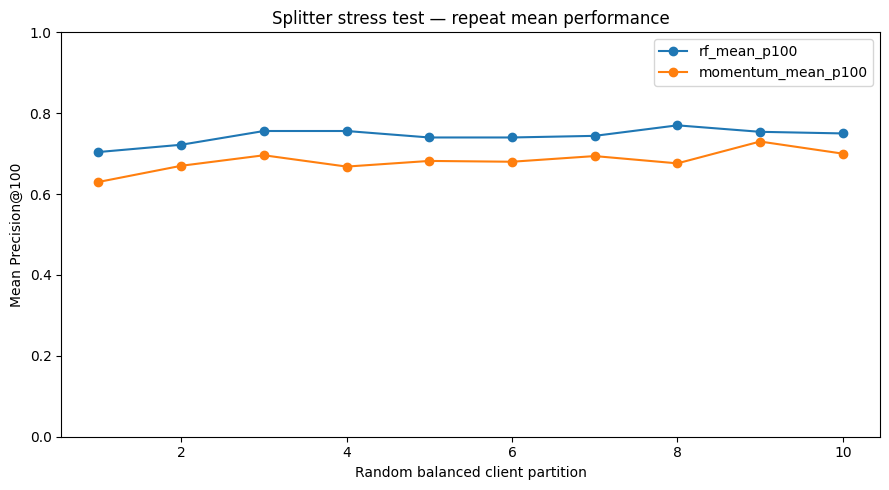

In [20]:
ax = repeat_summary.plot(
    x="repeat",
    y=["rf_mean_p100", "momentum_mean_p100"],
    marker="o",
    figsize=(9, 5),
)
ax.set_xlabel("Random balanced client partition")
ax.set_ylabel("Mean Precision@100")
ax.set_title("Splitter stress test — repeat mean performance")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 14. How to close the splitter question

Use this simple rule after **Run all**:

### We can close the splitter concern if:
- all 10 random partitions are unique;
- RF still stays broadly near the previous ~76% result;
- RF beats Momentum in most repeat means;
- the RF-vs-Momentum average lift remains positive.

In that case:

> The optimized splitter probably did reduce partition diversity, but the main Random Forest conclusion survives a deliberately more diverse balanced-client stress test.

### We should remain cautious if:
- the RF repeat means spread very widely;
- the average RF score shifts substantially;
- or RF loses to Momentum in many repeats.

In that case, the previous low 0.7 pp SD was partly an artifact of the optimized splitter.

### Important

This is a **sensitivity test on the same March cohort**.  
It is not a new independent test set and the repeat range is not a confidence interval.

After this test, we should stop changing splitters and write the final conclusion from the evidence we have.


In [21]:
PREVIOUS_OPT_RF_MEAN = 0.763
PREVIOUS_OPT_RF_BETWEEN_SD = 0.007
PREVIOUS_OPT_DELTA_PP = 3.7

mean_shift_pp = (random_rf_mean - PREVIOUS_OPT_RF_MEAN) * 100.0

print("=" * 78)
print("OPTIMIZED vs RANDOM-BALANCED — QUICK COMPARISON")
print("=" * 78)
print(f"Previous optimized RF mean:  {PREVIOUS_OPT_RF_MEAN:.1%}")
print(f"Random-balanced RF mean:     {random_rf_mean:.1%}")
print(f"Mean shift:                  {mean_shift_pp:+.1f} pp")
print()
print(f"Previous optimized RF SD:    {PREVIOUS_OPT_RF_BETWEEN_SD:.1%}")
print(f"Random-balanced RF SD:       {random_rf_between_sd:.1%}")
print()
print(f"Previous optimized RF lift:  {PREVIOUS_OPT_DELTA_PP:+.1f} pp")
print(f"Random-balanced RF lift:     {random_delta_mean:+.1f} pp")
print()
print(
    "Random-balanced repeat wins vs Momentum:",
    f"{repeat_wins}/{N_RANDOM_PARTITIONS}",
)
print()
print(
    "Send this cell plus the repeat-summary table back for the final interpretation."
)


OPTIMIZED vs RANDOM-BALANCED — QUICK COMPARISON
Previous optimized RF mean:  76.3%
Random-balanced RF mean:     74.4%
Mean shift:                  -1.9 pp

Previous optimized RF SD:    0.7%
Random-balanced RF SD:       1.9%

Previous optimized RF lift:  +3.7 pp
Random-balanced RF lift:     +6.1 pp

Random-balanced repeat wins vs Momentum: 10/10

Send this cell plus the repeat-summary table back for the final interpretation.
